In [4]:
import pandas as pd

In [5]:
#read
df=pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")

#check duplicates
df.duplicated().sum() 
df['authorities_contacted']=df['authorities_contacted'].fillna("Police")

#ensure consistency on column names
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)

#Rename Strings
df["collision_type"]=df["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
df["police_report_available"]=df["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
df["property_damage"]=df["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)

## Drop

In [6]:
# drop column as 100% nan-values
# drop umbrella limits as 80% of values are zeros, std = 1.1 Mio
df.drop(['months_as_customer',  'umbrella_limit',  'total_claim_amount', '_c39'],axis=1,inplace= True)

In [7]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
# #Type df.drop stuff
# for col in df.columns:
#     print(f"df.drop('{col}',axis=1,inplace=True)")

In [ ]:
df.drop('age',axis=1,inplace=True)
df.drop('policy_bind_date',axis=1,inplace=True)
df.drop('policy_state',axis=1,inplace=True)
df.drop('policy_csl',axis=1,inplace=True)
df.drop('policy_deductable',axis=1,inplace=True)
df.drop('policy_annual_premium',axis=1,inplace=True)
df.drop('insured_zip',axis=1,inplace=True)
df.drop('insured_sex',axis=1,inplace=True)
df.drop('insured_education_level',axis=1,inplace=True)
df.drop('insured_occupation',axis=1,inplace=True)
df.drop('insured_relationship',axis=1,inplace=True)
df.drop('capital_gains',axis=1,inplace=True)
df.drop('capital_loss',axis=1,inplace=True)
df.drop('incident_date',axis=1,inplace=True)
df.drop('incident_city',axis=1,inplace=True)
df.drop('incident_location',axis=1,inplace=True)
df.drop('incident_hour_of_the_day',axis=1,inplace=True)
df.drop('number_of_vehicles_involved',axis=1,inplace=True)
df.drop('property_damage',axis=1,inplace=True)
df.drop('bodily_injuries',axis=1,inplace=True)
df.drop('witnesses',axis=1,inplace=True)
df.drop('police_report_available',axis=1,inplace=True)
# df.drop('injury_claim',axis=1,inplace=True)
# df.drop('property_claim',axis=1,inplace=True)
# df.drop('vehicle_claim',axis=1,inplace=True)
df.drop('auto_make',axis=1,inplace=True)
df.drop('auto_model',axis=1,inplace=True)
df.drop('auto_year',axis=1,inplace=True)

In [ ]:
df.columns

Index(['insured_hobbies', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'injury_claim', 'property_claim', 'vehicle_claim', 'fraud_reported'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
LabelEnc = LabelEncoder()
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])

## Train Test Split  and X,y split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('fraud_reported', axis=1), df['fraud_reported'], test_size=0.2, random_state=42)


## Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

enc=OneHotEncoder(handle_unknown='ignore')
X_train_enc=enc.fit_transform(X_train[['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']]).toarray()
#dataframe
X_train_enc=pd.DataFrame(X_train_enc, columns=enc.get_feature_names_out(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']))

#reset index
X_train_enc.reset_index(drop=True, inplace=True)
X_train.reset_index(drop=True, inplace=True)

#concatenate
X_train=pd.concat([X_train, X_train_enc], axis=1)

#drop columns
X_train.drop(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state'], axis=1, inplace=True)

# same for test data
X_test_enc=enc.transform(X_test[['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']]).toarray()
X_test_enc=pd.DataFrame(X_test_enc, columns=enc.get_feature_names_out(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state']))
X_test_enc.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
X_test=pd.concat([X_test, X_test_enc], axis=1)
X_test.drop(['insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state'], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

minmax_scaler = MinMaxScaler()
rbst_scaler = RobustScaler()

minmax_col = [ "injury_claim",'vehicle_claim']
rbst_col = ['property_claim']


for column in minmax_col:
    X_train[column] = minmax_scaler.fit_transform(X_train[[column]])
    X_test[column] = minmax_scaler.fit_transform(X_test[[column]])
    
for column in rbst_col:
    X_train[column] = rbst_scaler.fit_transform(X_train[[column]])
    X_test[column] = rbst_scaler.transform(X_test[[column]])

In [ ]:
#df.to_csv('insurance_claims_clean.csv')
#X_train.to_csv("X_train_1.csv")
#X_test.to_csv("X_test_1.csv")

In [ ]:
X_train

,injury_claim,property_claim,vehicle_claim,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,...,authorities_contacted_Fire,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
0,0.66,1.17,0.80,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,0.31,-0.04,0.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
2,0.01,-1.04,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,0.04,-0.95,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,0.99,0.05,0.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.31,2.10,0.67,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
796,0.80,0.28,0.75,0.00,0.00,0.00,0.00,1.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
797,0.50,0.62,0.47,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
798,0.34,0.09,0.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00


## Logistic Regression

In [ ]:
# Log Reg
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
clf=LogisticRegression(C=1.0)
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)
# display crosstab without margins
display(pd.crosstab(y_test, y_pred, rownames=['Reality'], colnames=['Predicted'], margins=False))

#scores
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


Predicted,0,1
Reality,,
0,126,19
1,19,36


              precision    recall  f1-score   support

           0       0.87      0.87      0.87       145
           1       0.65      0.65      0.65        55

    accuracy                           0.81       200
   macro avg       0.76      0.76      0.76       200
weighted avg       0.81      0.81      0.81       200



In [ ]:
#proportions fraud_reported
df['fraud_reported'].value_counts(normalize=True)

fraud_reported
0   0.75
1   0.25
Name: proportion, dtype: float64

Considering the proportions of fraud reported, the model is performing decently (F1 score 0.76 on average). 

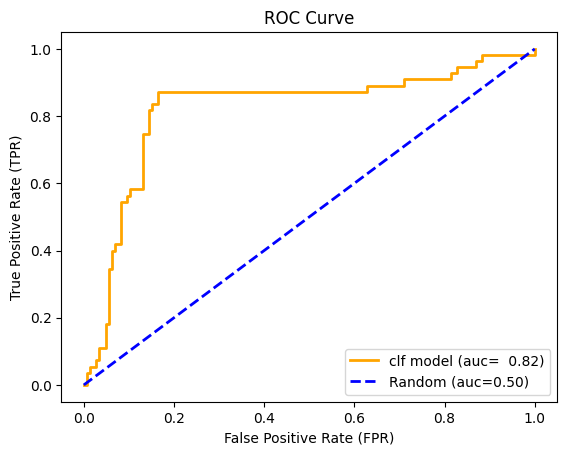

In [ ]:
# ROC Curve / AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
#calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:,1])
#calc AUC score
roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

plt.plot(fpr,tpr, color='orange', lw=2, label='clf model (auc= % 0.2f)'%roc_auc)
plt.plot([0,1], [0,1], color='blue', lw=2, linestyle= '--', label='Random (auc=0.50)')
#plt.xlim([0.0,1.0])
#plt.ylim([0.0,1.0])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

#roc_auc_score: Calculates the Area Under the ROC Curve (AUC). A higher AUC generally indicates a better model.


Interpretation of the Plot:

ROC Curve (Orange Line): This curve represents the performance of your classifier (clf). It shows the trade-off between the True Positive Rate (TPR, or Sensitivity) and the False Positive Rate (FPR, or 1 - Specificity) at various threshold settings.
AUC (Area Under the Curve): The AUC value (0.76 in this case) is a measure of the overall performance of the model. An AUC of 1 indicates a perfect classifier, while an AUC of 0.5 indicates a random classifier.
Random Classifier Line (Blue Dashed Line): This line represents a classifier that makes predictions randomly. Its AUC is always 0.5.
Performance: Since the AUC of your model (0.76) is higher than 0.5, it suggests that your classifier has some ability to distinguish between the positive and negative classes. The higher the AUC, the better the model's performance.

The area under the curve (AUC: Area Under the Curve) is very useful. In a single number, it summarizes the model's ability to distinguish the negative class from the positive class (Not Admitted / Admitted).

## SVM with a GridSearch

In [ ]:
#SVM
from sklearn.svm import SVC
clf = SVC(probability=True)
#GridSearch
from sklearn import model_selection
parameters= {'C':[0.1,1,10], 'kernel':['rbf', 'linear','poly'], 'gamma': [0.001, 0.1, 0.5]}
grid_clf= model_selection.GridSearchCV(estimator=clf, param_grid=parameters)
grid_clf.fit(X_train, y_train)
best_clf=grid_clf.best_estimator_
y_pred=best_clf.predict(X_test)
# display crosstab without margins
display(pd.crosstab(y_test, y_pred, rownames=['Reality'], colnames=['Predicted'], margins=False))
#classification report
print(classification_report(y_test, y_pred))
print('Best Parameters: ', grid_clf.best_params_)
print('Best Score: ', grid_clf.best_score_)
print('Best Estimator: ', grid_clf.best_estimator_)

Predicted,0,1
Reality,,
0,124,21
1,11,44


              precision    recall  f1-score   support

           0       0.92      0.86      0.89       145
           1       0.68      0.80      0.73        55

    accuracy                           0.84       200
   macro avg       0.80      0.83      0.81       200
weighted avg       0.85      0.84      0.84       200

Best Parameters:  {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
Best Score:  0.85625
Best Estimator:  SVC(C=1, gamma=0.001, kernel='linear', probability=True)


In [ ]:
#smote
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
#random oversampling
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
#random undersampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
#stratified fold
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

In [ ]:
import numpy as np

In [ ]:
#Lazypredict

import xgboost
print(xgboost.__version__)
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

3.0.0


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:03<00:00, 10.39it/s]

[LightGBM] [Info] Number of positive: 192, number of negative: 608
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240000 -> initscore=-1.152680
[LightGBM] [Info] Start training from score -1.152680
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LinearDiscriminantAnalysis,0.85,0.85,0.85,0.85,0.05
SVC,0.84,0.82,0.82,0.85,0.12
LinearSVC,0.83,0.81,0.81,0.84,0.05
RidgeClassifierCV,0.83,0.81,0.81,0.83,0.04
RidgeClassifier,0.83,0.81,0.81,0.83,0.03
NearestCentroid,0.81,0.81,0.81,0.81,0.03
ExtraTreesClassifier,0.84,0.81,0.81,0.85,0.39
BernoulliNB,0.81,0.80,0.80,0.82,0.04
SGDClassifier,0.81,0.79,0.79,0.81,0.06
